In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Get current working directory
os.getcwd()

'C:\\Users\\USER\\Downloads\\House_Prices_Prediction'

In [8]:
# load dataset
prop = pd.read_csv('./Properties.csv')
prop.head()

,page,title,description,bedrooms,bathrooms,toilets,garage,location,city,price
0,1,An Exquisite And Luxurious 3 Bedroom Apartment,3 bedroom flat / apartment for rent,3,3,4,3,"Ikoyi, Lagos",Ikoyi,15000000
1,1,2bedroom Apartment,2 bedroom flat / apartment for rent,2,2,3,0,"Oniru, Oniru, Victoria Island (VI), Lagos",Victoria Island,3500000
2,1,Executive 3 Bedroom Flat Serviced Apartment,3 bedroom flat / apartment for rent,3,3,3,2,"Prime Water Garden, Ikate, Lekki, Lagos",Lekki,4000000
3,1,Fantastic 1 Bedroom Mini Flat,1 bedroom mini flat (room and parlour) for rent,1,1,1,0,"Lekki Palm City, Ajah, Lagos",Ajah,1000000
4,1,Luxury,4 bedroom flat / apartment for rent,4,3,4,0,"Old Ikoyi, Ikoyi, Lagos",Ikoyi,12000000


In [9]:
prop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6573 entries, 0 to 6572
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   page         6573 non-null   int64 
 1   title        6573 non-null   object
 2   description  6573 non-null   object
 3   bedrooms     6573 non-null   int64 
 4   bathrooms    6573 non-null   int64 
 5   toilets      6573 non-null   int64 
 6   garage       6573 non-null   int64 
 7   location     6573 non-null   object
 8   city         6573 non-null   object
 9   price        6573 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 513.6+ KB


In [10]:
prop.describe()

,page,bedrooms,bathrooms,toilets,garage,price
count,6573.00000,6573.000000,6573.000000,6573.000000,6573.000000,6.573000e+03
mean,157.00000,2.139814,2.251331,2.801156,1.665906,1.065897e+07
std,90.36173,1.135422,1.069752,1.368785,1.771843,2.820651e+08
min,1.00000,0.000000,1.000000,1.000000,0.000000,2.500000e+04
25%,79.00000,1.000000,1.000000,1.000000,0.000000,1.000000e+06
50%,157.00000,2.000000,2.000000,3.000000,2.000000,2.000000e+06
75%,235.00000,3.000000,3.000000,4.000000,2.000000,5.000000e+06
max,313.00000,8.000000,8.000000,9.000000,9.000000,1.500000e+10


In [11]:
prop.head()

,page,title,description,bedrooms,bathrooms,toilets,garage,location,city,price
0,1,An Exquisite And Luxurious 3 Bedroom Apartment,3 bedroom flat / apartment for rent,3,3,4,3,"Ikoyi, Lagos",Ikoyi,15000000
1,1,2bedroom Apartment,2 bedroom flat / apartment for rent,2,2,3,0,"Oniru, Oniru, Victoria Island (VI), Lagos",Victoria Island,3500000
2,1,Executive 3 Bedroom Flat Serviced Apartment,3 bedroom flat / apartment for rent,3,3,3,2,"Prime Water Garden, Ikate, Lekki, Lagos",Lekki,4000000
3,1,Fantastic 1 Bedroom Mini Flat,1 bedroom mini flat (room and parlour) for rent,1,1,1,0,"Lekki Palm City, Ajah, Lagos",Ajah,1000000
4,1,Luxury,4 bedroom flat / apartment for rent,4,3,4,0,"Old Ikoyi, Ikoyi, Lagos",Ikoyi,12000000


In [12]:
#create new features
prop['estate_flag'] = prop['location'].apply(lambda x: len([c for c in str(x).lower().split() if "estate" in c]))
prop['terrace_flag'] = prop['title'].apply(lambda x: len([c for c in str(x).lower().split() if "terraced" 
                                                                  in c or "terrace" in c or "detached" in c
                                                                 or "duplex" in c]))
prop['luxury_flag'] = prop['title'].apply(lambda x: len([c for c in str(x).lower().split()
                                                              if "new" in c or "luxury" in c or "newly" in c
                                                              or "executive" in c or "luxurious" in c
                                                                        or "renovated" in c]))
prop['serviced_flag'] = prop['title'].apply(lambda x: len([c for c in str(x).lower().split()
                                                                           if "serviced" in c or "studio" in c]))
prop['miniflat_flag'] = prop['description'].apply(lambda x: len([c for c in str(x).lower().split() if "mini" in c]))
prop['selfcontain_flag'] = prop['description'].apply(lambda x: len([c for c in str(x).lower().split() if "self" in c]))

In [13]:
prop.head()

,page,title,description,bedrooms,bathrooms,toilets,garage,location,city,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,selfcontain_flag
0,1,An Exquisite And Luxurious 3 Bedroom Apartment,3 bedroom flat / apartment for rent,3,3,4,3,"Ikoyi, Lagos",Ikoyi,15000000,0,0,1,0,0,0
1,1,2bedroom Apartment,2 bedroom flat / apartment for rent,2,2,3,0,"Oniru, Oniru, Victoria Island (VI), Lagos",Victoria Island,3500000,0,0,0,0,0,0
2,1,Executive 3 Bedroom Flat Serviced Apartment,3 bedroom flat / apartment for rent,3,3,3,2,"Prime Water Garden, Ikate, Lekki, Lagos",Lekki,4000000,0,0,1,1,0,0
3,1,Fantastic 1 Bedroom Mini Flat,1 bedroom mini flat (room and parlour) for rent,1,1,1,0,"Lekki Palm City, Ajah, Lagos",Ajah,1000000,0,0,0,0,1,0
4,1,Luxury,4 bedroom flat / apartment for rent,4,3,4,0,"Old Ikoyi, Ikoyi, Lagos",Ikoyi,12000000,0,0,1,0,0,0


In [14]:
prop2 = prop.drop(['page', 'title','garage', 'description', 'location'], axis='columns')
prop2.head()

,bedrooms,bathrooms,toilets,city,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,selfcontain_flag
0,3,3,4,Ikoyi,15000000,0,0,1,0,0,0
1,2,2,3,Victoria Island,3500000,0,0,0,0,0,0
2,3,3,3,Lekki,4000000,0,0,1,1,0,0
3,1,1,1,Ajah,1000000,0,0,0,0,1,0
4,4,3,4,Ikoyi,12000000,0,0,1,0,0,0


In [15]:
corr= prop.corr()
corr

,page,bedrooms,bathrooms,toilets,garage,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,selfcontain_flag
page,1.000000,-0.038331,-0.027120,-0.047575,0.059881,-0.030325,0.008787,0.044774,0.031051,-0.001139,0.014659,0.018952
bedrooms,-0.038331,1.000000,0.891956,0.919705,0.131833,0.039941,0.004409,0.173949,0.145738,-0.020033,-0.466695,-0.607163
bathrooms,-0.027120,0.891956,1.000000,0.912229,0.197155,0.038894,0.029926,0.173219,0.162383,0.014270,-0.543808,-0.376856
toilets,-0.047575,0.919705,0.912229,1.000000,0.155302,0.054960,0.009744,0.155141,0.147100,0.008212,-0.611748,-0.414036
garage,0.059881,0.131833,0.197155,0.155302,1.000000,0.016880,0.039570,0.038833,0.131039,0.032851,-0.077451,-0.063119
price,-0.030325,0.039941,0.038894,0.054960,0.016880,1.000000,-0.012957,-0.000889,-0.016479,-0.007614,-0.014675,-0.010987
estate_flag,0.008787,0.004409,0.029926,0.009744,0.039570,-0.012957,1.000000,0.018014,0.067621,-0.043252,0.000706,0.029380
terrace_flag,0.044774,0.173949,0.173219,0.155141,0.038833,-0.000889,0.018014,1.000000,0.005405,-0.020873,-0.064916,0.001058
luxury_flag,0.031051,0.145738,0.162383,0.147100,0.131039,-0.016479,0.067621,0.005405,1.000000,0.000595,-0.047486,-0.129526
serviced_flag,-0.001139,-0.020033,0.014270,0.008212,0.032851,-0.007614,-0.043252,-0.020873,0.000595,1.000000,-0.036844,0.042020


<AxesSubplot:>

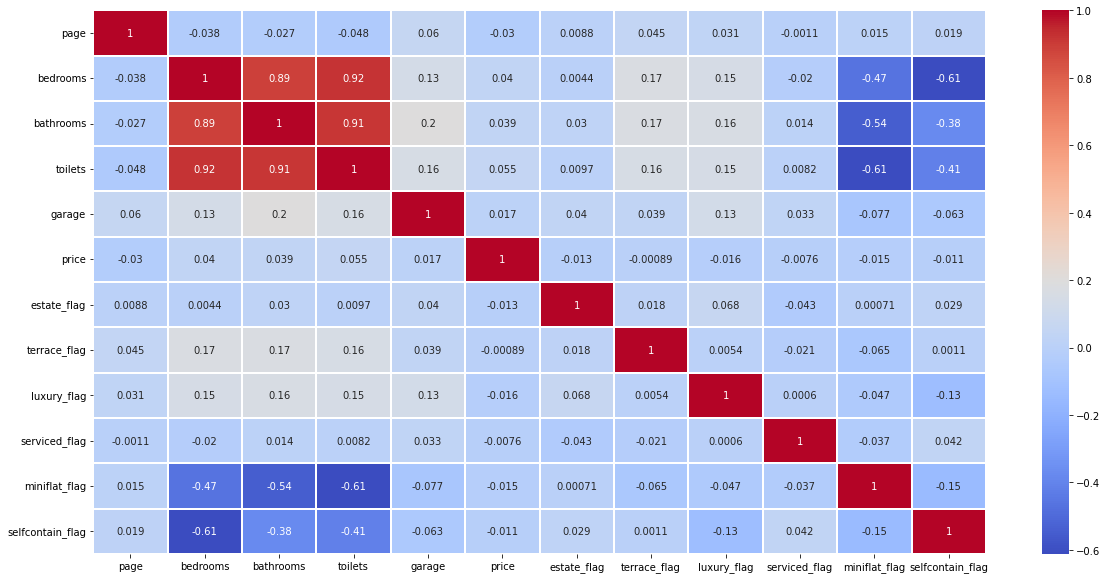

In [16]:
#corr
plt.figure(figsize=(20, 10))
sns.heatmap(corr,cmap='coolwarm',linewidths=2.0, annot=True)

In [17]:
prop2.isna().sum()

bedrooms            0
bathrooms           0
toilets             0
city                0
price               0
estate_flag         0
terrace_flag        0
luxury_flag         0
serviced_flag       0
miniflat_flag       0
selfcontain_flag    0
dtype: int64

In [18]:
def unique_(data, cols):
    for each in cols:
        x = data[each].unique()
        print("Unique values in", each, "column",x)

In [19]:
col = ['bedrooms', 'bathrooms', 'toilets']

In [20]:
unique_(prop2, col)

Unique values in bedrooms column [3 2 1 4 0 5 6 8 7]
Unique values in bathrooms column [3 2 1 4 5 6 8 7]
Unique values in toilets column [4 3 1 2 5 6 8 7 9]


In [21]:
prop2['city'].unique()

array(['Ikoyi', 'Victoria Island', 'Lekki', 'Ajah', 'North', 'Maryland',
       'Yaba', 'Ogudu', 'Ikeja', 'Ikorodu', 'Shomolu', 'Gbagada',
       'Magodo', 'Ilupeju', 'Surulere', 'Ketu', 'Odofin', 'Ojodu',
       'Ojota', 'Kosofe', 'Agege', 'Isolo', 'Mushin', 'Ijede', 'Ayobo',
       'Ipaja', 'Ikotun', 'Eko Atlantic City', 'Alimosho', 'Ojo',
       'Ifako-Ijaiye', 'Ijaiye', 'Epe', 'Island', 'Oshodi', 'Idimu',
       'Apapa'], dtype=object)

In [22]:
city_stats = prop2.groupby('city')['city'].agg('count').sort_values(ascending=False)
city_stats

city
Lekki                2391
Ajah                 1221
Ikoyi                1115
Victoria Island       420
Yaba                  199
Ikeja                 190
Surulere              153
Magodo                107
Gbagada               104
Ikorodu                96
Isolo                  78
Shomolu                68
Ojodu                  47
Ketu                   44
Maryland               43
Ogudu                  41
Ipaja                  40
North                  39
Agege                  35
Odofin                 23
Alimosho               17
Ayobo                  17
Eko Atlantic City      13
Ikotun                 11
Epe                    10
Ojo                    10
Ilupeju                 9
Ifako-Ijaiye            6
Island                  5
Ojota                   4
Kosofe                  4
Oshodi                  3
Apapa                   3
Mushin                  2
Ijaiye                  2
Ijede                   2
Idimu                   1
Name: city, dtype: int64

In [23]:
property_price = []
import numpy as np
for location in ['Ikoyi', 'Lekki', 'Ajah', 'Victoria Island', 'Shomolu', 'Maryland',
       'Surulere', 'Odofin', 'Ojodu', 'Yaba', 'Gbagada', 'Ikeja', 'Ojota',
       'Kosofe', 'Magodo', 'Agege', 'Ikorodu', 'Ketu', 'Ogudu', 'North',
       'Ilupeju', 'Isolo', 'Mushin', 'Ijede', 'Ayobo', 'Ipaja', 'Ikotun',
       'City', 'Alimosho', 'Ojo', 'Ifako-Ijaiye', 'Isheri', 'Ijaiye',
       'Epe', 'Island', 'Oshodi', 'Idimu', 'Apapa']:
    for i in range(1,6):
        d = {}
        d['city'] = location
        d['bedspace'] = i
        try:
            d['price_per_bedroom'] = np.percentile(prop2['price'][(prop2['city']==location)&(prop2['bedrooms']==i)],50)
        except (IndexError,TypeError) as e:
            d['price_per_bedroom'] = 0
        property_price.append(d)
        try:
            print("This is the median for {bed} bedroom in {location} : ".format(bed = i,location = location) ,np.percentile(prop2['price'][(prop2['city']==location)&(prop2['bedrooms']==i)],50))
        except (IndexError,TypeError) as e:
            print("This is the median for {bed} bedroom in {location} : ".format(bed = i,location = location) ,0)

This is the median for 1 bedroom in Ikoyi :  4000000.0
This is the median for 2 bedroom in Ikoyi :  8500000.0
This is the median for 3 bedroom in Ikoyi :  13000000.0
This is the median for 4 bedroom in Ikoyi :  13000000.0
This is the median for 5 bedroom in Ikoyi :  20000000.0
This is the median for 1 bedroom in Lekki :  1500000.0
This is the median for 2 bedroom in Lekki :  2500000.0
This is the median for 3 bedroom in Lekki :  3500000.0
This is the median for 4 bedroom in Lekki :  5000000.0
This is the median for 5 bedroom in Lekki :  7250000.0
This is the median for 1 bedroom in Ajah :  700000.0
This is the median for 2 bedroom in Ajah :  1200000.0
This is the median for 3 bedroom in Ajah :  1500000.0
This is the median for 4 bedroom in Ajah :  2500000.0
This is the median for 5 bedroom in Ajah :  3000000.0
This is the median for 1 bedroom in Victoria Island :  3000000.0
This is the median for 2 bedroom in Victoria Island :  5000000.0
This is the median for 3 bedroom in Victoria Isl

This is the median for 4 bedroom in Epe :  0
This is the median for 5 bedroom in Epe :  0
This is the median for 1 bedroom in Island :  25000.0
This is the median for 2 bedroom in Island :  1200000.0
This is the median for 3 bedroom in Island :  1400000.0
This is the median for 4 bedroom in Island :  0
This is the median for 5 bedroom in Island :  0
This is the median for 1 bedroom in Oshodi :  0
This is the median for 2 bedroom in Oshodi :  1000000.0
This is the median for 3 bedroom in Oshodi :  900000.0
This is the median for 4 bedroom in Oshodi :  0
This is the median for 5 bedroom in Oshodi :  0
This is the median for 1 bedroom in Idimu :  0
This is the median for 2 bedroom in Idimu :  700000.0
This is the median for 3 bedroom in Idimu :  0
This is the median for 4 bedroom in Idimu :  0
This is the median for 5 bedroom in Idimu :  0
This is the median for 1 bedroom in Apapa :  0
This is the median for 2 bedroom in Apapa :  0
This is the median for 3 bedroom in Apapa :  4000000.0
Th

In [24]:
pd.DataFrame(property_price)

,city,bedspace,price_per_bedroom
0,Ikoyi,1,4000000.0
1,Ikoyi,2,8500000.0
2,Ikoyi,3,13000000.0
3,Ikoyi,4,13000000.0
4,Ikoyi,5,20000000.0
...,...,...,...
185,Apapa,1,0.0
186,Apapa,2,0.0
187,Apapa,3,4000000.0
188,Apapa,4,4000000.0


In [25]:
#save the output in a dataframe and in order to merge with original dataframe
property_price=pd.DataFrame(property_price)
property_price['locationbed'] = property_price['city'] + property_price['bedspace'].astype(str)
property_price = property_price.drop(["city","bedspace"],axis=1)
property_price.head()

,price_per_bedroom,locationbed
0,4000000.0,Ikoyi1
1,8500000.0,Ikoyi2
2,13000000.0,Ikoyi3
3,13000000.0,Ikoyi4
4,20000000.0,Ikoyi5


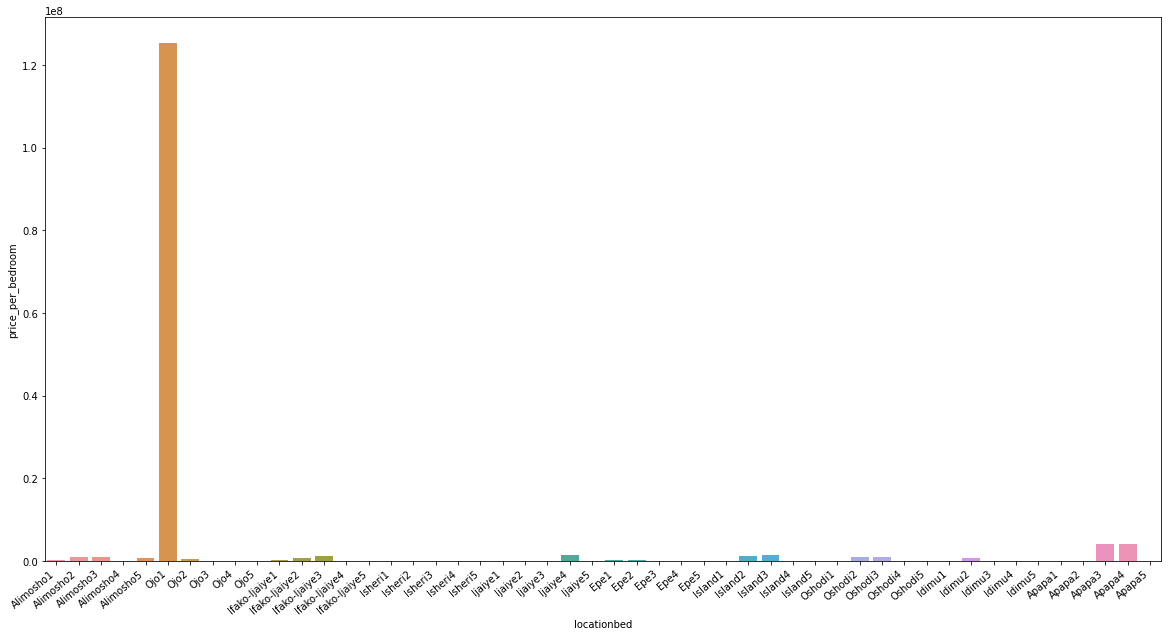

In [26]:
plt.figure(figsize=(20,10))
ax = sns.barplot(y='price_per_bedroom', x='locationbed', data=property_price.tail(50))
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

### Removing Outliers

In [27]:
prop.groupby('city')['price'].max().sort_values(ascending=False)

city
Ikoyi                15000000000
Victoria Island       8000000000
Lekki                 3000000000
Ojo                    250000000
Ikeja                   80000000
Magodo                  55000000
Eko Atlantic City       30000000
Ajah                    18000000
Surulere                10000000
Ilupeju                  9200000
Maryland                 7000000
Gbagada                  4800000
Apapa                    4000000
Ogudu                    3600000
Yaba                     3500000
North                    3000000
Shomolu                  3000000
Ojodu                    2500000
Ketu                     2500000
Agege                    2500000
Isolo                    2500000
Odofin                   2200000
Alimosho                 1500000
Ijaiye                   1500000
Island                   1500000
Ifako-Ijaiye             1300000
Ipaja                    1200000
Ikorodu                  1100000
Oshodi                   1000000
Mushin                    850000
Ikotu

### These Prices are too high for rent. These are outliers

In [28]:
prop2.shape

(6573, 11)

In [121]:
prop3 = prop2[~(prop2['price']>20000000)]

In [122]:
prop3.shape

(6461, 11)

In [123]:
def create_distplot(data,col):
    for i in range(len(col)):
        plt.figure()
        plot = data[col[i]].plot(kind='hist')
        plt.title(col[i])
        plt.show()

In [124]:
cols = ['bedrooms', 'bathrooms', 'toilets', 'price']

In [125]:
data = prop3.loc[:,['bedrooms', 'bathrooms', 'toilets', 'price']]

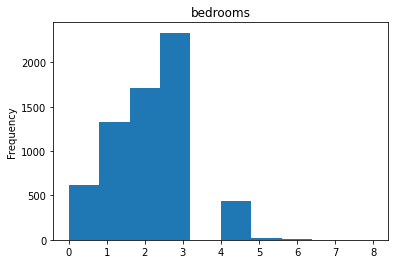

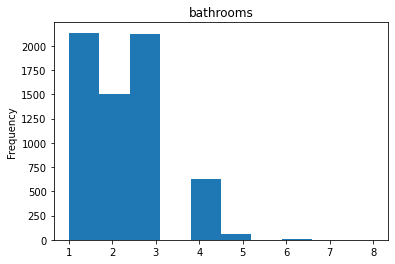

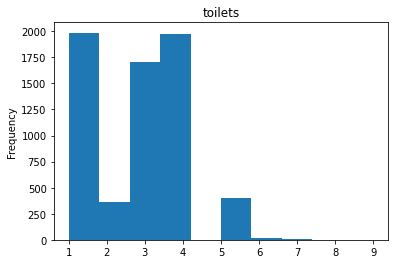

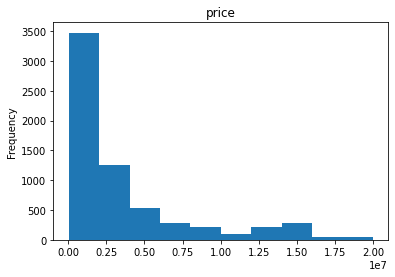

In [126]:
create_distplot(data, cols)

### Also, we check if number of bathrooms is greater than bedrooms and also if number of toilets is less than bathrooms

In [127]:
prop3.shape

(6461, 11)

In [128]:
prop4 = prop3[~(prop3['bathrooms']>prop3['bedrooms']+1)]

In [129]:
prop4.shape

(6440, 11)

In [130]:
prop5 = prop3[~(prop3['bathrooms']>prop3['toilets']+1)]

In [131]:
prop5.shape

(6436, 11)

In [132]:
prop5.head()

,bedrooms,bathrooms,toilets,city,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,selfcontain_flag
0,3,3,4,Ikoyi,15000000,0,0,1,0,0,0
1,2,2,3,Victoria Island,3500000,0,0,0,0,0,0
2,3,3,3,Lekki,4000000,0,0,1,1,0,0
3,1,1,1,Ajah,1000000,0,0,0,0,1,0
4,4,3,4,Ikoyi,12000000,0,0,1,0,0,0


In [133]:
dummies = pd.get_dummies(prop5['city'])
dummies.head()

,Agege,Ajah,Alimosho,Apapa,Ayobo,Eko Atlantic City,Epe,Gbagada,Idimu,Ifako-Ijaiye,...,Odofin,Ogudu,Ojo,Ojodu,Ojota,Oshodi,Shomolu,Surulere,Victoria Island,Yaba
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [134]:
prop6 = pd.concat([prop5, dummies.drop('Yaba',axis=1)], axis=1)
prop6.head()

,bedrooms,bathrooms,toilets,city,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,...,North,Odofin,Ogudu,Ojo,Ojodu,Ojota,Oshodi,Shomolu,Surulere,Victoria Island
0,3,3,4,Ikoyi,15000000,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,3,Victoria Island,3500000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,3,3,Lekki,4000000,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,Ajah,1000000,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,4,3,4,Ikoyi,12000000,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [135]:
prop7 = prop6.drop('city',axis=1)
prop7.head()

,bedrooms,bathrooms,toilets,price,estate_flag,terrace_flag,luxury_flag,serviced_flag,miniflat_flag,selfcontain_flag,...,North,Odofin,Ogudu,Ojo,Ojodu,Ojota,Oshodi,Shomolu,Surulere,Victoria Island
0,3,3,4,15000000,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,3,3500000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,3,3,4000000,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1000000,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,3,4,12000000,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [136]:
prop7.shape

(6436, 46)

In [137]:
X = prop7.drop('price', axis=1)
y = prop7['price']

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.791070595799873

In [140]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cv
# ShuffleSplit will randomize the sample so each of the fold have eqaul distribution of my data samples

ShuffleSplit(n_splits=5, random_state=0, test_size=0.2, train_size=None)

In [141]:
cross_val_score(lr, X, y, cv=cv)

array([0.78242848, 0.78766196, 0.77549186, 0.78021397, 0.78534656])

## Hyperparamater tunning

### Using Grid Search CV to find the best model

In [142]:
def find_best_model(X,y):
    models = {
        'linear_regression':{
            'model':LinearRegression(),
            'params':{'normalize':[True, False]
            }
        },
        'random_forest':{
            'model':RandomForestRegressor(),
            'params':{
                'criterion' :['mse']
                }
        },
        'lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
        },
        'decision_tree':{
            'model':DecisionTreeRegressor(),
            'params':{
                'criterion':['mse','friedman_mse'],
                'splitter':['best','random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for model_name, config in models.items():
        gridsearch = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gridsearch.fit(X,y)
        scores.append({
            'model': model_name,
            'best_score':gridsearch.best_score_,
            'best_params':gridsearch.best_params_
        })
        
    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

In [143]:
find_best_model(X,y)

,model,best_score,best_params
0,linear_regression,0.782229,{'normalize': False}
1,random_forest,0.811816,{'criterion': 'mse'}
2,lasso,0.782229,"{'alpha': 2, 'selection': 'random'}"
3,decision_tree,0.800354,"{'criterion': 'mse', 'splitter': 'best'}"


In [144]:
rfr = RandomForestRegressor(criterion='mse',random_state=42)
rfr.fit(X_train, y_train)
rfr.score(X_test, y_test)

0.8362145743229437

In [145]:
dtr = DecisionTreeRegressor(criterion='mse', splitter='best',random_state=42)
dtr.fit(X_train,y_train)
dtr.score(X_test,y_test)

0.8214142770050283

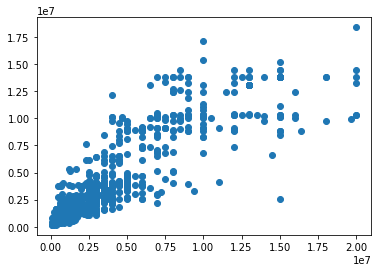

In [146]:
plt.scatter(y_test,rfr.predict(X_test))

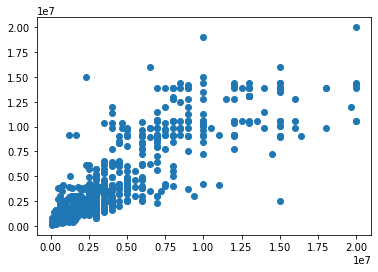

In [147]:
plt.scatter(y_test,dtr.predict(X_test))

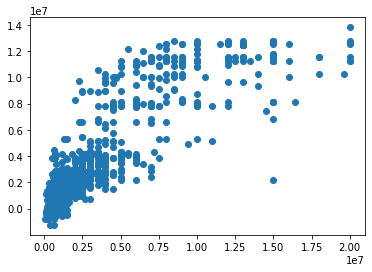

In [148]:
plt.scatter(y_test,lr.predict(X_test))

### Let's predict prices

In [151]:
def predict_price(city,bedroom,bathroom,toilet):
    loc_index = np.where(X.columns==city)[0][0]
    
    x = np.zeros(len(X.columns))
    x[0] = bedroom
    x[1] = bathroom
    x[2] = toilet
    if loc_index >= 0 :
        x[loc_index] = 1
        
    return rfr.predict([x])[0]

In [152]:
predict_price('Lekki',1,1,1)

1378244.347945961

In [154]:
predict_price('Ikoyi',4,4,5)

12419922.705707423

### Exporting the model to disk

In [155]:
import pickle
with open('Lagos_properties_price_model.pickle','wb') as f:
    pickle.dump(rfr, f)